# Gantt Chart Generator

# Library

In [1]:
import os
import re

import numpy as np
import pandas as pd
import plotly.express as px
from great_tables import GT, style, loc
from datetime import datetime

# Variable

In [2]:
timelineSheet = "Timeline"
informationSheet = "Information"

# Load Data

In [3]:
exelRe = re.compile(r"^[^\~].*.xlsx$")
rsltRe = re.compile(r"\.xlsx$")
excelFile = [f for f in os.listdir() if exelRe.match(f)]
excelFile = sorted(excelFile)[0]
outputFile = rsltRe.sub("", excelFile) + ".html"

print(f"Input File: {excelFile = }")
print(f"Output File: {outputFile = }")

Input File: excelFile = 'Timeline.xlsx'
Output File: outputFile = 'Timeline.html'


In [4]:
df = pd.read_excel(excelFile, sheet_name=None)

# Information Sheet
info = df[informationSheet]

# Timeline Sheet
tl = df[timelineSheet]

# Project Information

In [5]:
projectName = info.loc[info["Variable"] == "projectName", "Value"].item()
goLiveDate = info.loc[info["Variable"] == "goLiveDate", "Value"].item()
prevTaskComment = info.loc[info["Variable"] == "prevTaskComment", "Value"].item()
prevTaskStart = info.loc[info["Variable"] == "prevTaskStart", "Value"].item()

print(f"{projectName = }")
print(f"{goLiveDate = }")
print(f"{prevTaskComment = }")
print(f"{prevTaskStart = }")

projectName = 'Database Upgrade'
goLiveDate = '2026-04-29'
prevTaskComment = 'Before 9 a.m.'
prevTaskStart = '08:00:00'


# Pre-Processing

In [6]:
tl["PlotStart"] = np.where(tl["Start"].isna(), prevTaskStart, tl["Start"])
tl["PlotFinish"] = tl["Finish"]

In [7]:
tl["PlotStart"] = pd.to_datetime(goLiveDate  + " " + tl["PlotStart"].astype(str))
tl["PlotFinish"] = pd.to_datetime(goLiveDate  + " " + tl["PlotFinish"].astype(str))

In [8]:
tl = tl.sort_values("PlotStart")

In [9]:
tl["Start"] = np.where(tl["Start"].isna(), prevTaskComment, tl["Start"])

In [10]:
timeRex1 = r"^(\d{2}:\d{2}):\d{2}$"
timeRex2 = r"\1"

tl["Start"] = tl["Start"].astype(str).str.replace(timeRex1, timeRex2, regex=True)
tl["Finish"] = tl["Finish"].astype(str).str.replace(timeRex1, timeRex2, regex=True)
tl["Duration"] = tl["Duration"].astype(str).str.replace(timeRex1, timeRex2, regex=True)

# Schedule Table

In [11]:
columns = ["No", "Category", "Predecessors", "Start", "Finish", "Duration", "Task", "CheckPoint", "Assignee"]
table_display = (
    GT(tl[columns], groupname_col="Category")
    .tab_header(title="Schedule Table")
    .cols_align(
        align="left", 
        columns=["Task", "CheckPoint"]
    )
    .tab_style(
        style=style.borders(sides="right", color="lightgray", weight="1px"),
        locations=loc.body(columns=columns) 
    )
    .tab_style(
        style=style.borders(sides="right", color="lightgrey", weight="1px"),
        locations=loc.column_labels(columns=columns)
    )
    .tab_style(
        style=style.css("white-space: pre-wrap;"),
        locations=loc.body(columns=["Task", "CheckPoint"])
    )
)
table_html = table_display.as_raw_html()

display(table_display)

GT(_tbl_data=    No        Category Predecessors          Start Finish Duration  \
0    1     Preparation          NaN  Before 9 a.m.  09:00      NaN   
1    2     Preparation          NaN  Before 9 a.m.  09:00      NaN   
3    4        Lockdown            1  Before 9 a.m.  09:00      NaN   
2    3     Preparation            2          09:00  10:00    01:00   
4    5     Data Backup            4          09:00  11:00    02:00   
5    6       Execution         3, 5          11:00  14:00    03:00   
6    7       Execution            6          14:00  16:00    02:00   
7    8      Validation            6          14:00  15:30    01:30   
8    9      Validation         7, 8          16:00  18:00    02:00   
9   10  Post-Migration            9          18:00  19:00    01:00   
10  11  Post-Migration           10          19:00  19:30    00:30   

                                                 Task  \
0                Announcement of cutover commencement   
1    Verification of network routing & firewall rules   
3     Termination of user sessions & login suspension   
2         Execution of pre-migration application jobs   
4       Full database backup & integrity verification   
5                 Database schema migration & upgrade   
6        Application configuration & software upgrade   
7      DB index rebuilding & performance optimisation   
8        Application Integration Testing (Smoke Test)   
9         Initialisation of monitoring & log analysis   
10  Client's Approval\nFinal authorisation for go-...   

                                        CheckPoint             Assignee  
0            Notify all stakeholders of the start.               Client  
1          Ensure connectivity between DB servers.  Infrastructure Team  
3   Establish a static point for data consistency.               Client  
2          Clear queues and finalise transactions.     Application Team  
4        Create a restoration point for roll-back.  Infrastructure Team  
5                              Critical path task.  Infrastructure Team  
6              Update database connection strings.     Application Team  
7        Optimise performance after data transfer.  Infrastructure Team  
8      Joint verification for business resumption.    App Team & Client  
9       Commence production environment monitoring  Infrastructure Team  
10         Formal sign-off for project completion.               Client  , _body=<great_tables._gt_data.Body object at 0x000002388C058A10>, _boxhead=Boxhead([ColInfo(var='No', type=<ColInfoTypeEnum.default: 1>, column_label='No', column_align='right', column_width=None), ColInfo(var='Category', type=<ColInfoTypeEnum.row_group: 3>, column_label='Category', column_align='left', column_width=None), ColInfo(var='Predecessors', type=<ColInfoTypeEnum.default: 1>, column_label='Predecessors', column_align='right', column_width=None), ColInfo(var='Start', type=<ColInfoTypeEnum.default: 1>, column_label='Start', column_align='left', column_width=None), ColInfo(var='Finish', type=<ColInfoTypeEnum.default: 1>, column_label='Finish', column_align='right', column_width=None), ColInfo(var='Duration', type=<ColInfoTypeEnum.default: 1>, column_label='Duration', column_align='right', column_width=None), ColInfo(var='Task', type=<ColInfoTypeEnum.default: 1>, column_label='Task', column_align='left', column_width=None), ColInfo(var='CheckPoint', type=<ColInfoTypeEnum.default: 1>, column_label='CheckPoint', column_align='left', column_width=None), ColInfo(var='Assignee', type=<ColInfoTypeEnum.default: 1>, column_label='Assignee', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002388E4653D0>, _spanners=Spanners([]), _heading=Heading(title='Schedule Table', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002388E459B80>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002388E6CC380>, _source_notes=[], _footnotes=[

# Gantt Chart

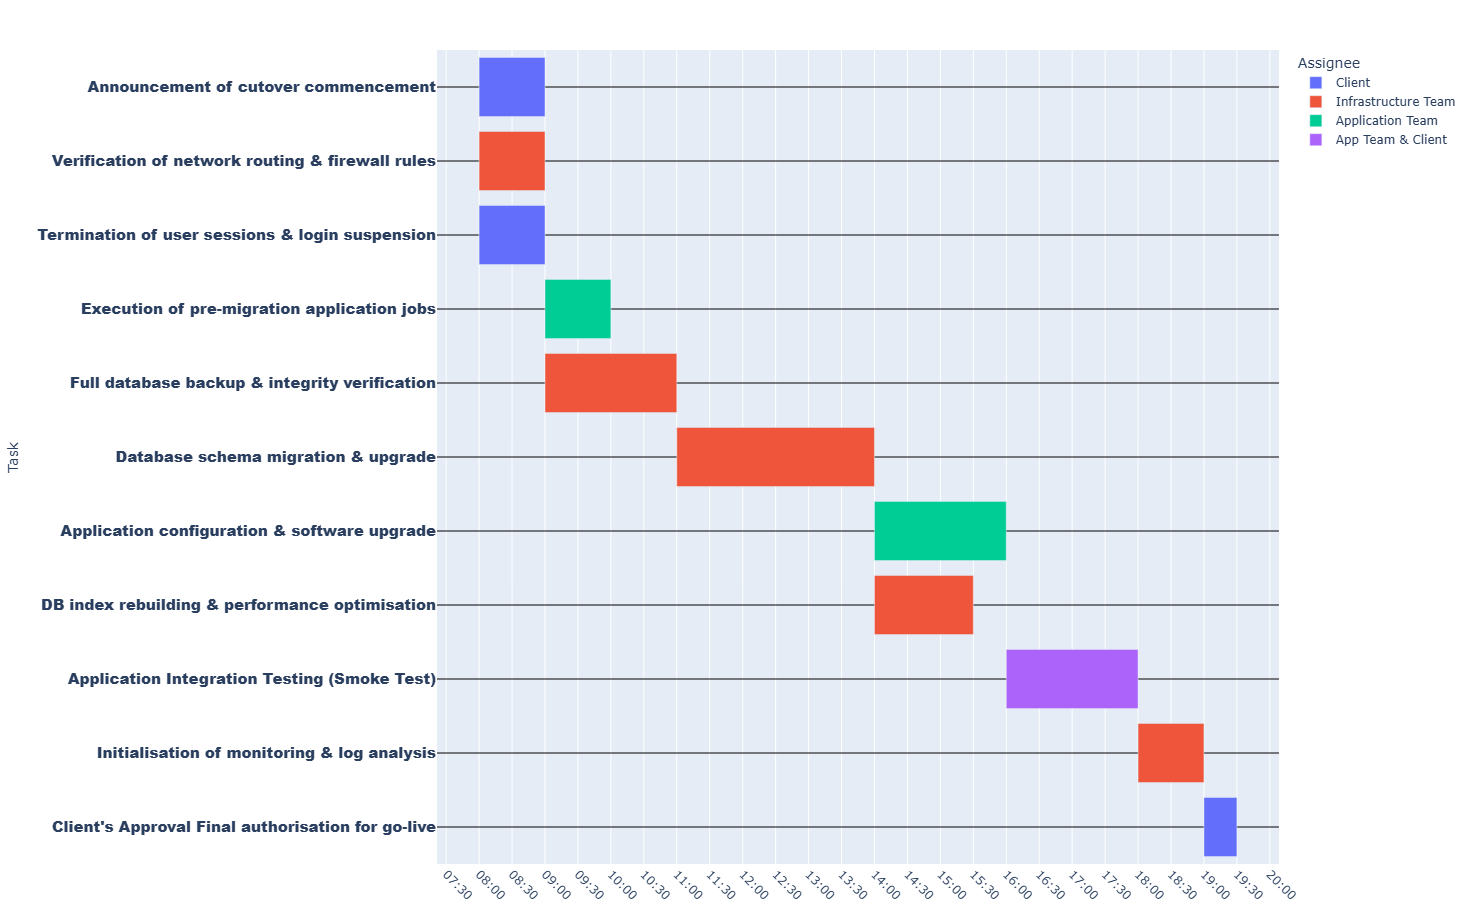

In [12]:
fig = px.timeline(tl, x_start="PlotStart", x_end="PlotFinish", y="Task", color="Assignee", width=1600, height=900)

fig.update_yaxes(
    categoryorder="array",
    categoryarray=tl["Task"].unique(),
    autorange="reversed",
    showgrid=True,         # Display Grid
    gridwidth=1,           # Line Width
    # gridcolor='LightGrey', # Line Colour
    gridcolor="Black", # Line Colour
    #griddash="dot"        # Style
    tickfont=dict(size=15, family="Arial Black")
)

fig.update_xaxes(
    tickangle=45
)

fig.update_layout(
    autosize=False,
    margin=dict(l=50, r=50, t=50, b=50),
    xaxis=dict(tickformat="%H:%M", dtick=1800000)
)

fig.show()

# Output

In [13]:
chart_html = fig.to_html(full_html=True, include_plotlyjs='cdn')

In [14]:
combined_html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8" />
    <title>{projectName}</title>
    <style>
        body {{ font-family: sans-serif; margin: 40px; }}
        .container {{ margin-bottom: 50px; }}
        h1 {{ text-align: center; color: #333333; margin-top: 50px; font-family: sans-serif; }}
    </style>
</head>
<body>
    <h1>{projectName} Timeline</h1>
    <div class="container">
        {table_html}
    </div>
    <h1>{projectName} Gantt Chart</h1>
    <div class="container">
        {chart_html}
    </div>
</body>
</html>
"""

In [15]:
with open(outputFile, "w", encoding="utf-8") as f:
    f.write(combined_html)